In [ ]:
import os
import sys
import joblib
import numpy as np
import pandas as pd
import xgboost as xgb
import logging
from pathlib import Path


sys.path.insert(0, 'YOUR-PATH/actionable-hypotension/utils')
sys.path.insert(0, 'YOUR-PATH/actionable-hypotension')

from db_interface import get_engine
import matplotlib.pyplot as plt
from sklearn.calibration import calibration_curve

from calibration.utils.calibration_functions import load_calibrate_and_save_model_unbundled

CWD: /fs/dss/work/rirg2545/actionable-hypotension/calibration

--- sys.path ---
/dss/work/rirg2545/actionable-hypotension
/dss/work/rirg2545/actionable-hypotension/calibration
/dss/work/rirg2545/actionable-hypotension
/dss/work/rirg2545/actionable-hypotension/utils
/user/rirg2545/miniconda3/envs/hypotension/lib/python310.zip
/user/rirg2545/miniconda3/envs/hypotension/lib/python3.10
/user/rirg2545/miniconda3/envs/hypotension/lib/python3.10/lib-dynload

/user/rirg2545/miniconda3/envs/hypotension/lib/python3.10/site-packages


### Configuration

In [ ]:
UNCALIBRATED_MODELS_DIR = "YOUR-PATH/actionable-hypotension/models_given/uncalibrated"
CALIBRATED_MODELS_DIR = "YOUR-PATH/actionable-hypotension/extended_evaluation_review/models_calibrated_unbundled"

### Calibrate XGBoost Models

In [4]:
load_calibrate_and_save_model_unbundled(model_name="xgb_inv", table_name="merged_inv_features", drop_treatment_given=True, drop_only_2_values=True)
load_calibrate_and_save_model_unbundled(model_name="xgb_mix", table_name="merged_mix_features", drop_treatment_given=True, drop_only_2_values=True)
load_calibrate_and_save_model_unbundled(model_name="xgb_noninv", table_name="merged_noninv_features", drop_treatment_given=True, drop_only_2_values=True)

CWD: /fs/dss/work/rirg2545/actionable-hypotension/calibration

--- sys.path ---
/dss/work/rirg2545/actionable-hypotension
/dss/work/rirg2545/actionable-hypotension/calibration
/dss/work/rirg2545/actionable-hypotension
/dss/work/rirg2545/actionable-hypotension/utils
/user/rirg2545/miniconda3/envs/hypotension/lib/python310.zip
/user/rirg2545/miniconda3/envs/hypotension/lib/python3.10
/user/rirg2545/miniconda3/envs/hypotension/lib/python3.10/lib-dynload

/user/rirg2545/miniconda3/envs/hypotension/lib/python3.10/site-packages
Saved calibrator for xgb_inv
CWD: /fs/dss/work/rirg2545/actionable-hypotension/calibration

--- sys.path ---
/dss/work/rirg2545/actionable-hypotension
/dss/work/rirg2545/actionable-hypotension/calibration
/dss/work/rirg2545/actionable-hypotension
/dss/work/rirg2545/actionable-hypotension/utils
/user/rirg2545/miniconda3/envs/hypotension/lib/python310.zip
/user/rirg2545/miniconda3/envs/hypotension/lib/python3.10
/user/rirg2545/miniconda3/envs/hypotension/lib/python3.10/

### Apply calibrated model

In [ ]:
def load_and_prepare_data_xgb(table_name, drop_treatment_given=False, drop_only_2_values=False):

    logging.info(f"Loading val/test data from ce_approach.{table_name}")
    engine = get_engine()
    df = pd.read_sql(f"""
        SELECT * FROM ce_approach.{table_name}
        WHERE split IN ('val', 'test')
    """, engine)

    drop_cols = ["subject_id", "icustay_id", "context_start", "context_end"]
    df = df.drop(columns=[c for c in drop_cols if c in df.columns])
    
    
    df["label"] = df["positive_event"].astype(int)

    excluded = {"positive_event", "positive_sample", "split", "label"}
    
    if drop_treatment_given:
        df = df.drop(columns=["treatment_given"])
    if drop_only_2_values:
        df = df.drop(columns=["only_2_values"])
    
    FEATURE_COLS = [c for c in df.columns if c not in excluded]

    val_df  = df[df["split"] == "val"]
    test_df = df[df["split"] == "test"]

    X_VAL = val_df[FEATURE_COLS]
    Y_VAL = val_df["label"]
    X_TEST = test_df[FEATURE_COLS]
    Y_TEST = test_df["label"]

    logging.info("Data loaded and cached.")
    return X_VAL, Y_VAL, X_TEST, Y_TEST, FEATURE_COLS


In [ ]:
def plot_calibration_from_model(
    calibrated_model,
    X: pd.DataFrame,
    y: pd.Series,
    class_name: str
):
    """
    Plots the calibration curve for a calibrated model.

    Args:
        calibrated_model: An object with `predict_proba(X)` method (e.g. CalibratedXGBModel)
        X: Features
        y: Labels
        class_name: Name for saving and labeling the plot
        figures_dir: Directory to save the figure
    """

    # Get calibrated predictions on test set
    calibrated_probs_test = calibrated_model.predict_proba(X)

    # Calibration curve and ECE
    prob_true, prob_pred = calibration_curve(y, calibrated_probs_test, n_bins=10, strategy='quantile')
    bin_counts = np.histogram(calibrated_probs_test, bins=10)[0]
    total = np.sum(bin_counts)
    valid_bins = min(len(prob_true), len(prob_pred), len(bin_counts))
    ece = np.sum((bin_counts[:valid_bins] / total) * np.abs(prob_true[:valid_bins] - prob_pred[:valid_bins]))

    fig = plt.figure(figsize=(8, 6))
    plt.plot(prob_pred, prob_true, marker='o', linestyle=':', label=f'Calibration error {ece:.6f}', color='red', linewidth=3)
    plt.plot([0, 1], [0, 1], color='black', linewidth=3)
    max_val = max(prob_pred.max(), prob_true.max())
    plt.xlim(0, max_val * 1.05)
    plt.ylim(0, max_val * 1.05)
    plt.xlabel('Mean predicted probability', fontsize=16)
    plt.ylabel('True probability', fontsize=16)
    plt.title(f"Calibration Plot – {class_name}", fontsize=16)
    plt.legend(fontsize=16, framealpha=0)
    plt.grid(True)
    plt.tight_layout()
    plt.tick_params(axis='both', labelsize=12)
    fig.patch.set_alpha(0.0)
    fig.set_facecolor('none')

    plt.show()
    plt.close()


In [6]:
x_val, y_val, x_test, y_test, feature_cols = load_and_prepare_data_xgb("merged_noninv_features", drop_treatment_given=True, drop_only_2_values=True)

In [7]:
model_name = "xgb_noninv"
calibrated_model = joblib.load(os.path.join(CALIBRATED_MODELS_DIR, f"{model_name}.pkl"))

In [8]:
y_test_calibrated = calibrated_model.predict_proba(x_test)

In [9]:
y_test_calibrated

array([1.9987959e-03, 1.9987959e-03, 8.6772918e-05, ..., 2.6776630e-05,
       4.5675045e-04, 1.8847434e-04], shape=(668808,), dtype=float32)

In [10]:
y_test_pred = calibrated_model.booster.predict(xgb.DMatrix(x_test))

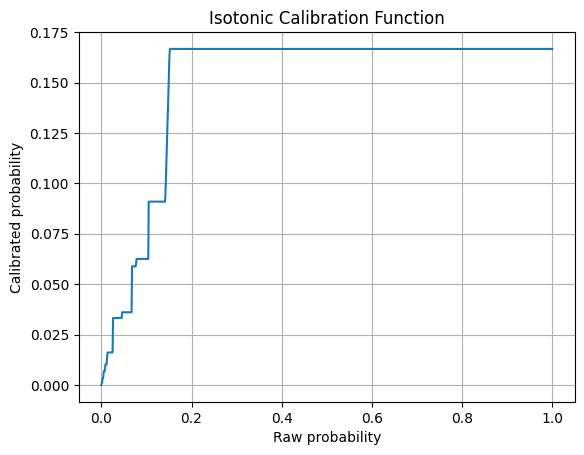

In [11]:
import matplotlib.pyplot as plt

probs = np.linspace(0, 1, 1000)
plt.plot(probs, calibrated_model.calibrator.transform(probs))
plt.title("Isotonic Calibration Function")
plt.xlabel("Raw probability")
plt.ylabel("Calibrated probability")
plt.grid(True)
plt.show()

In [12]:
y_test_pred

array([1.7150554e-03, 2.4332174e-03, 1.5129159e-04, ..., 8.9657704e-05,
       5.5381306e-04, 2.3323591e-04], shape=(668808,), dtype=float32)

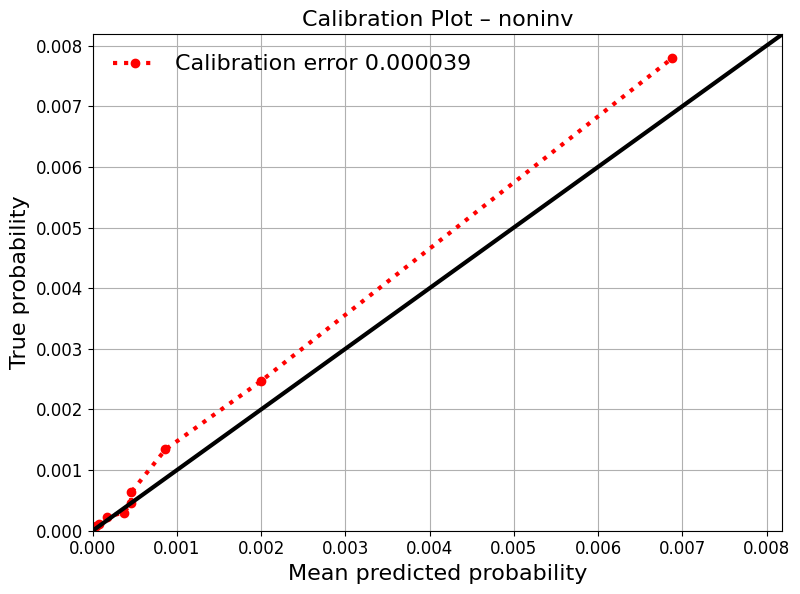

In [14]:
plot_calibration_from_model(
    calibrated_model=calibrated_model,
    X=x_test,
    y=y_test,
    class_name="noninv"
)